#**Integration of Word2Vec-Based Sequential Clustering and PageRank Topological Analysis for Identifying Authority Hubs in Amazon Product Metadata**  

---
##**PRELIMINARY SETUP**
---

###**Libraries**

In [ ]:
!pip install pyspark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.4/455.4 MB 884.9 kB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.0/203.0 kB 20.5 MB/s eta 0:00:00
  Created wheel for pyspark: filename=pyspark-4.1.2-py2.py3-none-any.whl size=456079515 sha256=0fba238be88df39eab0cdd572f292bc11456a2a8e7f62e5cd9cbed0cd543a51b
  Stored in directory: /root/.cache/pip/wheels/e6/9c/35/b08622081a09dc48b9467b570ae170519430915aa3c8d27cf9
Successfully built pyspark


In [ ]:
import os
import shutil, gzip, requests
from google.colab import drive
from tqdm.notebook import tqdm
from scipy.stats import spearmanr, chisquare
from sklearn.preprocessing import StandardScaler
from pyspark import SparkContext
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import Word2Vec
from pyspark.sql.window import Window
from pyspark.ml.linalg import VectorUDT
from pyspark.sql.types import (
    StructType, StructField, StringType, FloatType, IntegerType,
    LongType, BooleanType, ArrayType, MapType,
)
import pyarrow.parquet as pq
import networkx as nx
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

###**Load Dataset**

In [ ]:
drive.mount("/content/drive")
DRIVE_DIR = "/content/drive/MyDrive/Amazon/DATASETS" #Create this first in your Google Drive and change the path.
WORK_DIR = "/content/work"
OUTPUT_DIR = f"{DRIVE_DIR}/outputs"

os.makedirs(f"{WORK_DIR}/spark_tmp", exist_ok=True)
os.makedirs(f"{WORK_DIR}/checkpoints", exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok = True)

print(f"Drive has been mounted. Data location: {DRIVE_DIR}")

Mounted at /content/drive
Drive has been mounted. Data location: /content/drive/MyDrive/Amazon/DATASETS


###**PySpark Initialization**

In [ ]:
#----------PRELIMINARY SPARK SESSION CLEANING----------
try:
  active_session = SparkSession.getActiveSession()
  if active_session is not None:
    print("Shutting down active Spark sessions")
    active_session.stop()
    print("Sucessfully terminated active Spark sessions")

  sc = SparkContext._active_spark_context
  if sc is not None:
    print("Shutting down loose Spark Context")
    sc.stop()
    print("Successfully Terminated Legacy Spark Context")

except Exception as e:
  print(f"No open sessions or loose Spark Context found during flush: {str(e)}")

#----------INITIALIZE SPARK SESSION----------
spark = (SparkSession.builder
    .appName("AmazonCourseProject")
    .master("local[*]")
    .config("spark.driver.memory", "12g")
    .config("spark.driver.maxResultSize", "2g")
    .config("spark.sql.shuffle.partitions", "64")
    .config("spark.local.dir", f"{WORK_DIR}/spark_tmp")
    .config("spark.sql.adaptive.enabled", "true")
    .getOrCreate())

spark.sparkContext.setCheckpointDir(f"{WORK_DIR}/checkpoints")
print(f"PySpark Initialized.\n Web UI: {spark.sparkContext.uiWebUrl}")

PySpark Initialized.
 Web UI: http://76f5f75d3e26:4040


---
##**PROJECT PROPER**
---

###**Dataset Configuration**

In [ ]:
#----------PATHS----------
DRIVE_DIR = "/content/drive/MyDrive/Amazon/DATASETS"
WORK_DIR  = "/content/work"
os.makedirs(DRIVE_DIR, exist_ok=True)
os.makedirs(WORK_DIR, exist_ok=True)

def local(path):
    return os.path.join(WORK_DIR, os.path.basename(path))

In [ ]:
#----------DATA DICTIONARY----------
metadata_schema = StructType([
    StructField("main_category",   StringType()),
    StructField("title",           StringType()),
    StructField("average_rating",  FloatType()),
    StructField("rating_number",   IntegerType()),
    StructField("features",        ArrayType(StringType())),
    StructField("description",     ArrayType(StringType())),
    StructField("price",           FloatType()),
    StructField("images",          ArrayType(StructType([
        StructField("thumb",   StringType()),
        StructField("large",   StringType()),
        StructField("hi_res",  StringType()),
        StructField("variant", StringType()),
    ]))),
    StructField("videos",          ArrayType(StructType([
        StructField("title", StringType()),
        StructField("url",   StringType()),
    ]))),
    StructField("store",           StringType()),
    StructField("categories",      ArrayType(StringType())),
    StructField("details",         MapType(StringType(), StringType())),
    StructField("parent_asin",     StringType()),
    StructField("bought_together", ArrayType(StringType())),
])

reviews_schema = StructType([
    StructField("rating",            FloatType()),
    StructField("title",             StringType()),
    StructField("text",              StringType()),
    StructField("images",            ArrayType(StructType([
        StructField("small_image_url",  StringType()),
        StructField("medium_image_url", StringType()),
        StructField("large_image_url",  StringType()),
    ]))),
    StructField("asin",              StringType()),
    StructField("parent_asin",       StringType()),
    StructField("user_id",           StringType()),
    StructField("timestamp",         LongType()),
    StructField("verified_purchase", BooleanType()),
    StructField("helpful_vote",      IntegerType()),
])

datasets = {
    "metadata": {
        "url": "https://mcauleylab.ucsd.edu:8443/public_datasets/data/amazon_2023/raw/meta_categories/meta_Home_and_Kitchen.jsonl.gz",
        "gz": "./DATASETS/meta_Home_and_Kitchen.jsonl.gz",
        "parquet": "./DATASETS/meta_Home_and_Kitchen.parquet",
        "schema": metadata_schema
    },
    "reviews": {
        "url": "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/Home_and_Kitchen.jsonl.gz",
        "gz": "./DATASETS/Home_and_Kitchen.jsonl.gz",
        "parquet": "./DATASETS/Home_and_Kitchen.parquet",
        "schema": reviews_schema
    }
}

In [ ]:
#----------DATA FUNCTIONS----------
def download(gz, url):
    print(f"Downloading {url}")
    tmp = gz + ".part"
    with requests.get(url, stream = True, timeout = 60) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        with open(tmp, "wb") as f, tqdm(
            total = total, unit = "B", unit_scale = True,
            desc = os.path.basename(gz), leave=False,
        ) as bar:
            for chunk in r.iter_content(chunk_size = 4 * 1024 * 1024):
                f.write(chunk)
                bar.update(len(chunk))
    os.replace(tmp, gz)
    print(f"Saved {gz}\n")

def ensure_jsonl(d):
    local_gz    = local(d["gz"])
    local_jsonl = local_gz[:-3]  #strip .gz

    if os.path.exists(local_jsonl):
        print(f"Located {local_jsonl}")
        return local_jsonl

    if not os.path.exists(local_gz):
        if os.path.exists(d["gz"]):
            print(f"Staging gz from Drive -> {local_gz}")
            shutil.copy(d["gz"], local_gz)
        else:
            download(local_gz, d["url"])
            print("Mirroring gz to Drive for persistence")
            shutil.copy(local_gz, d["gz"])

    print(f"Decompressing {local_gz} -> {local_jsonl}")
    tmp = local_jsonl + ".part"
    with gzip.open(local_gz, "rb") as src, open(tmp, "wb") as dst:
        shutil.copyfileobj(src, dst, length = 16 * 1024 * 1024)
    os.replace(tmp, local_jsonl)
    return local_jsonl

def clean(d):
    jsonl = ensure_jsonl(d)
    local_parquet = local(d["parquet"])

    print(f"Reading {jsonl}")
    df = spark.read.schema(d["schema"]).json(jsonl)   # splittable; no repartition needed
    df.write.mode("overwrite").parquet(local_parquet)

    print(f"Removing temp file {jsonl}")
    os.remove(jsonl)

    print(f"Mirroring parquet to Drive -> {d['parquet']}")
    if os.path.exists(d["parquet"]):
        shutil.rmtree(d["parquet"])
    shutil.copytree(local_parquet, d["parquet"])
    print(f"Saved {d['parquet']}\n")

def create(name):
    d = datasets[name]
    local_parquet = local(d["parquet"])

    if not os.path.exists(local_parquet):
        if os.path.exists(d["parquet"]):
            print(f"Staging parquet from Drive -> {local_parquet}")
            shutil.copytree(d["parquet"], local_parquet)
        else:
            clean(d)
    else:
        print(f"Located {local_parquet}")

    return spark.read.parquet(local_parquet)

In [ ]:
for name in datasets:
    d = datasets[name]
    # Reconstruct the 'gz' and 'parquet' paths using DRIVE_DIR to ensure they are absolute
    d["gz"] = os.path.join(DRIVE_DIR, os.path.basename(d["gz"]))
    d["parquet"] = os.path.join(DRIVE_DIR, os.path.basename(d["parquet"]))

metadata_df = create("metadata")
reviews_df = create("reviews")

meta_Home_and_Kitchen.jsonl.gz:   0%|          | 0.00/2.96G [00:00<?, ?B/s]

Saved /content/work/meta_Home_and_Kitchen.jsonl.gz

Mirroring gz to Drive for persistence
Decompressing /content/work/meta_Home_and_Kitchen.jsonl.gz -> /content/work/meta_Home_and_Kitchen.jsonl
Reading /content/work/meta_Home_and_Kitchen.jsonl
Removing temp file /content/work/meta_Home_and_Kitchen.jsonl
Mirroring parquet to Drive -> /content/drive/MyDrive/Amazon/DATASETS/meta_Home_and_Kitchen.parquet
Saved /content/drive/MyDrive/Amazon/DATASETS/meta_Home_and_Kitchen.parquet



Home_and_Kitchen.jsonl.gz:   0%|          | 0.00/8.31G [00:00<?, ?B/s]

Saved /content/work/Home_and_Kitchen.jsonl.gz

Mirroring gz to Drive for persistence
Decompressing /content/work/Home_and_Kitchen.jsonl.gz -> /content/work/Home_and_Kitchen.jsonl
Reading /content/work/Home_and_Kitchen.jsonl
Removing temp file /content/work/Home_and_Kitchen.jsonl
Mirroring parquet to Drive -> /content/drive/MyDrive/Amazon/DATASETS/Home_and_Kitchen.parquet
Saved /content/drive/MyDrive/Amazon/DATASETS/Home_and_Kitchen.parquet



In [ ]:
#----------PARQUET UNCOMPRESSED FILESIZEs----------
def get_parquet_size(path):
    if not os.path.exists(path):
        return None

    try:
        total = 0
        dataset = pq.ParquetDataset(path)
        for frag in dataset.fragments:
            md = frag.metadata
            for i in range(md.num_row_groups):
                rg = md.row_group(i)
                for j in range(rg.num_columns):
                    total += rg.column(j).total_uncompressed_size
        return total
    except Exception as e:
        print(f"ERROR reading {path}: {e}")
        return None

print("PARQUET UNCOMPRESSED SIZES")

total_bytes = 0
for name, d in datasets.items():
    path = d["parquet"]
    size = get_parquet_size(path)

    if size is None:
        local_path = f"/content/work/{os.path.basename(path)}"
        if os.path.exists(local_path):
            print(f"{name} (checking local copy)")
            path = local_path
            size = get_parquet_size(path)

    if size is not None:
        mb = size / (1024 * 1024)
        gb = size / (1024 * 1024 * 1024)
        print(f"{name:12} -> {mb:>10,.0f} MB ({gb:>6.2f} GB)")
        total_bytes += size
    else:
        print(f"{name:12} -> NOT FOUND")

total_mb = total_bytes / (1024 * 1024)
total_gb = total_bytes / (1024 * 1024 * 1024)
print(f"{'TOTAL':12} --> {total_mb:>10,.0f} MB ({total_gb:>6.2f} GB)")

PARQUET UNCOMPRESSED SIZES
metadata     ->      8,313 MB (  8.12 GB)
reviews      ->     19,089 MB ( 18.64 GB)
TOTAL        -->     27,403 MB ( 26.76 GB)


###**Feature Extraction**

In [ ]:
#----------LOAD REVIEWS----------
reviews_df = spark.read.parquet(f"{DRIVE_DIR}/Home_and_Kitchen.parquet")

reviews_filter = reviews_df.select("user_id", "parent_asin", "timestamp")

#Count purchases per user
user_counts = reviews_filter.groupBy("user_id").agg(
    F.count("*").alias("num_purchases")
)

#Keep users with 3-100 purchases
valid_users = (user_counts
    .filter((F.col("num_purchases") >= 3) & (F.col("num_purchases") <= 100))
    .select("user_id")
    .cache())

valid_count = valid_users.count()
print(f"Found {valid_count:,} valid users (3-100 purchases each)")

#Filter reviews to only valid users
reviews_filtered = reviews_filter.join(F.broadcast(valid_users), "user_id", "inner")

print(f"Filtered dataset is ready.")
reviews_filtered.show(5)

Found 7,123,444 valid users (3-100 purchases each)
Filtered dataset is ready.
+--------------------+-----------+-------------+
|             user_id|parent_asin|    timestamp|
+--------------------+-----------+-------------+
|AFJM3YTM2KHUPXCWI...| B0000BYBYM|1395631781000|
|AFJM3YTM2KHUPXCWI...| B007YZ7CYQ|1395631570000|
|AFJM3YTM2KHUPXCWI...| B00E4GWNCY|1394918583000|
|AFJM3YTM2KHUPXCWI...| B00FCQOG84|1391805446000|
|AFJM3YTM2KHUPXCWI...| B06W5556VR|1391219582000|
+--------------------+-----------+-------------+
only showing top 5 rows


In [ ]:
#----------USER PURCHASE SEQUENCES----------

#Check if sequences is cached in Drive
sequences_path = f"{DRIVE_DIR}/user_sequences.parquet"

if os.path.exists(sequences_path):
    print(f"Found cached sequences at {sequences_path}")
    user_sequences = spark.read.parquet(sequences_path)
else:
    user_sequences = (reviews_filtered
        .groupBy("user_id")
        .agg(
            F.collect_list(
                F.struct("timestamp", "parent_asin")
            ).alias("purchases")
        )
        .withColumn(
            "sequence",
            F.expr("transform(array_sort(purchases), x -> x.parent_asin)")
        )
        .select("user_id", "sequence")
        .filter(F.size("sequence") >= 3)  # need at least 3 purchases for meaningful patterns
    )

    #Cache in memory for Word2Vec training
    user_sequences = user_sequences.cache()

    #Force evaluation and save checkpoint
    seq_count = user_sequences.count()
    print(f"\nCreated {seq_count:,} user sequences")

    #Save to Drive as checkpoint
    user_sequences.write.mode("overwrite").parquet(sequences_path)

print("\nSample sequences:")
user_sequences.select("user_id", F.size("sequence").alias("num_products")).show(10)


Created 7,123,444 user sequences

Sample sequences:
+--------------------+------------+
|             user_id|num_products|
+--------------------+------------+
|AE224VNJJFX76NIM4...|           5|
|AE22636FPSP6EPOO6...|           6|
|AE226AGBKOAEE2VBN...|           3|
|AE22A3QA745UXUYJI...|           7|
|AE22BBN7KYYHGDRLK...|           8|
|AE22BGROKKXTN3B64...|           8|
|AE22DM2QR6U6MD64V...|           3|
|AE22KWT5NXSFQIFB6...|          12|
|AE22PTAOIZLE7XDV7...|           3|
|AE22RBMTQSWVDKHBQ...|           4|
+--------------------+------------+
only showing top 10 rows


In [ ]:
#----------WORD2VEC TRAINING----------
embeddings_path = f"{DRIVE_DIR}/embeddings.parquet"

if os.path.exists(embeddings_path):
    print(f"\nEmbeddings already exist at {embeddings_path}")
    print("Delete this file if you retraining.")
    product_embeddings = spark.read.parquet(embeddings_path)
else:
    print("\nTraining Word2Vec model...")
    print("vectorSize = 128, minCount = 5, maxIter = 10")

    w2v = Word2Vec(
        vectorSize = 64,
        minCount = 10,
        numPartitions = 16,
        maxIter = 5,
        stepSize = 0.025,
        inputCol = "sequence",
        outputCol = "vector"
    )

    print("\n   Training started...")
    w2v_model = w2v.fit(user_sequences)
    print("Training complete.")

    #Extract product embeddings
    product_embeddings = w2v_model.getVectors()

    #Show vocabulary size
    vocab_size = product_embeddings.count()
    print(f"\nLearned embeddings for {vocab_size:,} products")

    # Save to Drive
    product_embeddings.write.mode("overwrite").parquet(embeddings_path)


Training Word2Vec model...
vectorSize = 128, minCount = 5, maxIter = 10

   Training started...
Training complete.

Learned embeddings for 570,300 products


In [ ]:
#----------Validation Check----------

#Show sample embeddings
print("\nSample product embeddings:")
product_embeddings.show(5, truncate=False)

#Check vector dimensions
vec_size = product_embeddings.select("vector").first()[0].size
print(f"\nVector dimension: {vec_size}")
print(f"Total products with embeddings: {product_embeddings.count():,}")


Sample product embeddings:
+----------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

###**PageRank (Co-Review Graph)**

In [ ]:
#----------LOAD REVIEWS AND METADATA----------

#Stage reviews to local
local_reviews = f"{WORK_DIR}/Home_and_Kitchen.parquet"
if not os.path.exists(local_reviews):
    print("Staging reviews from Google Drive")
    shutil.copytree(f"{DRIVE_DIR}/Home_and_Kitchen.parquet", local_reviews)
    print("Staged")
else:
    print(f"Found local reviews")

reviews = spark.read.parquet(local_reviews)

# Stage metadata
local_metadata = f"{WORK_DIR}/meta_Home_and_Kitchen.parquet"
if not os.path.exists(local_metadata):
    print("Staging metadata from Google Drive")
    shutil.copytree(f"{DRIVE_DIR}/meta_Home_and_Kitchen.parquet", local_metadata)
    print("Staged")
else:
    print(f"Found local metadata")

metadata = spark.read.parquet(local_metadata)

print(f"\nReviews loaded")
print(f"Metadata loaded")

Found local reviews
Found local metadata

Reviews loaded
Metadata loaded


In [ ]:
#----------TOP PRODUCTS BY REVIEW COUNT----------

#Count reviews per product
product_counts = (reviews
    .groupBy("parent_asin")
    .agg(F.count("*").alias("review_count"))
    .orderBy(F.desc("review_count")))

#Top 5000 products
TOP_N = 5000
top_products = product_counts.limit(TOP_N).cache()

num_top = top_products.count()
print(f"\n✓ Selected top {num_top:,} products")

#Distribution Visual
top_products.selectExpr(
    "review_count",
    "percent_rank() OVER (ORDER BY review_count DESC) * 100 as percentile"
).show(10)


✓ Selected top 5,000 products
+------------+--------------------+
|review_count|          percentile|
+------------+--------------------+
|       84739|                 0.0|
|       43521|0.020004000800160033|
|       42783|0.040008001600320066|
|       41356|0.060012002400480095|
|       41147| 0.08001600320064013|
|       39731| 0.10002000400080016|
|       38783| 0.12002400480096019|
|       37321| 0.14002800560112022|
|       33044| 0.16003200640128026|
|       32119| 0.18003600720144028|
+------------+--------------------+
only showing top 10 rows


In [ ]:
#----------CREATE EDGES (Prodcuts rev. by same user)----------

#Filter reviews to only top products
reviews_filtered = reviews.join(
    top_products.select("parent_asin"),
    "parent_asin"
).select("user_id", "parent_asin").distinct().cache()

print(f"Filtered user-product pairs: {reviews_filtered.count():,}")

#Create edges with explicit column names
edges = (reviews_filtered.alias("a")
    .join(reviews_filtered.alias("b"), "user_id")
    .filter("a.parent_asin < b.parent_asin")  # avoid duplicates
    .select(
        F.col("a.parent_asin").alias("src"),
        F.col("b.parent_asin").alias("dst")
    )
    .groupBy("src", "dst")
    .agg(F.count("*").alias("weight"))  # count co-reviews
    .filter("weight >= 3")  # require at least 3 shared users
)

#Save intermediate result
edges_path = f"{WORK_DIR}/co_review_edges.parquet"
edges.write.mode("overwrite").parquet(edges_path)
print(f"Edges saved to {edges_path}")

edges = spark.read.parquet(edges_path).cache()
edge_count = edges.count()
print(f"Created {edge_count:,} edges (products with 3+ shared reviewers)")

Filtered user-product pairs: 15,369,921
Edges saved to /content/work/co_review_edges.parquet
Created 1,440,422 edges (products with 3+ shared reviewers)


In [ ]:
#----------PageRank on NetworkX----------

#Collect edges to driver (NetworkX runs in-memory)
print("Collecting edges to driver...")
edges_pd = edges.select("src", "dst", "weight").toPandas()  # ← CHANGED

print(f"Collected {len(edges_pd):,} edges")

#Build NetworkX graph
print("Building NetworkX graph...")
G = nx.from_pandas_edgelist(
    edges_pd,
    source='src',
    target='dst',
    edge_attr='weight',
    create_using=nx.Graph()
)

print(f"Graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

#PageRank
print("Running PageRank")
pagerank_scores = nx.pagerank(
    G,
    alpha = 0.85,
    max_iter = 50,
    tol = 1e-6
)

print("PageRank complete")

Collected 1,440,422 edges
Building NetworkX graph...
Graph: 5,000 nodes, 1,440,422 edges
Running PageRank
PageRank complete


In [ ]:
#----------ADD PRODUCT METADATA----------

#Convert to Spark DataFrame
pr_df = spark.createDataFrame(
    [(k, float(v)) for k, v in pagerank_scores.items()],
    ["parent_asin", "pagerank"]
)

#Join with metadata
results = pr_df.join(
    metadata.select("parent_asin", "title", "average_rating", "features"),
    "parent_asin"
).join(
    top_products.select("parent_asin", "review_count"),
    "parent_asin"
)

#Save to Drive
output_path = f"{DRIVE_DIR}/pagerank_co_review.parquet"
results.write.mode("overwrite").parquet(output_path)

####**Results**

#####**Top Products by PageRank**

In [ ]:
results.orderBy(F.desc("pagerank")).select(
    "parent_asin",
    "title",
    F.col("pagerank").cast("decimal(10,8)"),
    "review_count",
    "average_rating"
).show(20, truncate = 50)

+-----------+--------------------------------------------------+----------+------------+--------------+
|parent_asin|                                             title|  pagerank|review_count|average_rating|
+-----------+--------------------------------------------------+----------+------------+--------------+
| B0B53DWRVW|Mellanni RV Bedding Short Queen - Double Brushe...|0.00801351|       84739|           4.5|
| B00U8QEXBS|Amazon Basics Lightweight Super Soft Easy Care ...|0.00578518|       42783|           4.6|
| B0BSPGR5T6|Instant Pot Duo 7-in-1 Electric Pressure Cooker...|0.00540242|       41147|           4.7|
| B0C7LZYYWQ|SafeRest Mattress Protector - Twin XL - College...|0.00507852|       43521|           4.6|
| B0BZJP9VGZ|ZINUS SmartBase Heavy Duty Mattress Foundation ...|0.00467088|       39731|           4.7|
| B01NBTD4Q8|1500 Supreme Collection Twin XL Sheet Sets Lila...|0.00409728|       41356|           4.6|
| B0BZJNL66N|Zinus 8 Inch Green Tea Memory Foam Mattress / C...|

#####**Comparison: PageRank Ranking vs Popularity Ranking**

In [ ]:
#Add ranks
results_ranked = results.withColumn(
    "pagerank_rank",
    F.row_number().over(Window.orderBy(F.desc("pagerank")))
).withColumn(
    "popularity_rank",
    F.row_number().over(Window.orderBy(F.desc("review_count")))
).withColumn(
    "rank_difference",
    F.abs(F.col("pagerank_rank") - F.col("popularity_rank"))
)

#Products where PageRank differs most from popularity
print("\nProducts with highest rank difference (PageRank finds hidden gems):")
results_ranked.orderBy(F.desc("rank_difference")).select(
    "title",
    "pagerank_rank",
    "popularity_rank",
    "rank_difference",
    "review_count",
    F.col("pagerank").cast("decimal(10,8)")
).show(15, truncate = 40)

#Compute Spearman correlation
print("\nComputing correlation...")
results_pd = results.select("pagerank", "review_count").toPandas()
corr, pval = spearmanr(results_pd['pagerank'], results_pd['review_count'])
print(f"Spearman correlation: {corr:.3f} (p-value: {pval:.2e})")
if corr < 0.7:
    print("PageRank captures different influence than raw popularity.")
else:
    print("PageRank and popularity are highly correlated.")


Products with highest rank difference (PageRank finds hidden gems):
+----------------------------------------+-------------+---------------+---------------+------------+----------+
|                                   title|pagerank_rank|popularity_rank|rank_difference|review_count|  pagerank|
+----------------------------------------+-------------+---------------+---------------+------------+----------+
|OXO Good Grips Silicone Basting & Pas...|          933|           4889|           3956|        1360|0.00025774|
|ZAMAT Adjustable Cervical Memory Foam...|         4779|           1021|           3758|        3826|0.00004583|
|IMINSO Handheld Vacuum Cordless Car V...|         4783|           1050|           3733|        3767|0.00004568|
|OXO Salt and Pepper Shaker Set, Clear...|         1317|           4787|           3470|        1384|0.00019493|
|Cuisipro Silver Measuring Spoon Set, ...|         1397|           4852|           3455|        1369|0.00018476|
|Electric Blanket Heated Th

###**K-Means Clustering**

In [ ]:
#----------K-Means Clustering----------

#Load embeddings
embeddings = spark.read.parquet(f"{DRIVE_DIR}/embeddings.parquet")
embeddings = embeddings.withColumnRenamed("word", "parent_asin")

#K-Means Execution
kmeans = KMeans(k=50, featuresCol = "vector", seed = 42, maxIter = 20)
model = kmeans.fit(embeddings)
clusters = model.transform(embeddings)

#Save results
clusters.select("parent_asin", "prediction").write.mode("overwrite") \
    .parquet(f"{DRIVE_DIR}/clusters.parquet")

print("K-means Clustering complete")

K-means Clustering complete


###**Merge and Result Validation**

In [ ]:
#----------LOAD RESULTS----------

#Word2Vec embeddings
embeddings = spark.read.parquet(f"{DRIVE_DIR}/embeddings.parquet")
embeddings = embeddings.withColumnRenamed("word", "parent_asin")  # if not already renamed
print(f"Embeddings: {embeddings.count():,} products")

#PageRank scores (co-review graph)
pagerank = spark.read.parquet(f"{DRIVE_DIR}/pagerank_co_review.parquet")  # ← CHANGED
print(f"PageRank: {pagerank.count():,} products")

#K-Means clusters
clusters = spark.read.parquet(f"{DRIVE_DIR}/clusters.parquet")
print(f"Clusters: {clusters.count():,} assignments")

#Original metadata
metadata = spark.read.parquet(f"{DRIVE_DIR}/meta_Home_and_Kitchen.parquet")
print(f"Metadata: {metadata.count():,} products")

Embeddings: 570,300 products
PageRank: 5,000 products
Clusters: 570,300 assignments
Metadata: 3,735,584 products


In [ ]:
#----------JOIN DATASETS----------

#Join: embeddings → clusters → pagerank → metadata
final = (embeddings
    .join(pagerank.select("parent_asin", "pagerank", "review_count"), "parent_asin", "left")
    .join(clusters, "parent_asin", "inner")
    .join(metadata.select("parent_asin", "title", "average_rating"), "parent_asin", "left")
)

#Cache for multiple analyses
final = final.cache()
final_count = final.count()
print(f"Merged dataset: {final_count:,} products")

#Schema
final.printSchema()

#Sample
print("\nSample rows:")
final.select("parent_asin", "prediction", "pagerank", "review_count", "title").show(5, truncate=50)

Merged dataset: 570,300 products
root
 |-- parent_asin: string (nullable = true)
 |-- vector: vector (nullable = true)
 |-- pagerank: double (nullable = true)
 |-- review_count: long (nullable = true)
 |-- prediction: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- average_rating: float (nullable = true)


Sample rows:
+-----------+----------+--------+------------+--------------------------------------------------+
|parent_asin|prediction|pagerank|review_count|                                             title|
+-----------+----------+--------+------------+--------------------------------------------------+
| 089886531X|        14|    NULL|        NULL|Mac's Field Guide: Bad Garden Bugs of The Pacif...|
| 0981698638|         7|    NULL|        NULL|The Gathering of Friends Volume 5 - Come Gather...|
| 1605168416|         7|    NULL|        NULL|Jesus “Prince of Peace” Double Matted, 16’ X 20...|
| B00002N636|         7|    NULL|        NULL|        Hoover 4010001A T

####**TEST: Cluster Analysis**

In [ ]:
#----------BEHAVIORAL CLUSTERS ANALYSIS----------

#Aggregate by cluster
cluster_stats = (final
    .filter("pagerank IS NOT NULL")  #Only products in both datasets
    .groupBy("prediction")
    .agg(
        F.count("*").alias("products"),
        F.avg("pagerank").alias("avg_pagerank"),
        F.avg("review_count").alias("avg_review_count"),
        F.avg("average_rating").alias("avg_rating")
    )
    .orderBy(F.desc("avg_pagerank"))
)

print("\nTop 10 clusters by average PageRank:")
cluster_stats.show(10, truncate = False)

#Find high-influence clusters
print("\nClusters with above-average PageRank:")
overall_avg_pr = final.filter("pagerank IS NOT NULL").agg(F.avg("pagerank")).first()[0]
high_influence_clusters = cluster_stats.filter(f"avg_pagerank > {overall_avg_pr}")
print(f"Found {high_influence_clusters.count()} / 50 clusters with above-average influence")


Top 10 clusters by average PageRank:
+----------+--------+---------------------+------------------+------------------+
|prediction|products|avg_pagerank         |avg_review_count  |avg_rating        |
+----------+--------+---------------------+------------------+------------------+
|21        |315     |3.41692029598165E-4  |4617.453968253968 |4.4403174347347685|
|6         |215     |3.119715661909169E-4 |3170.0558139534883|4.632092994867369 |
|7         |216     |2.7265356747493654E-4|3366.3611111111113|4.481944415304396 |
|37        |89      |2.611588990614502E-4 |2435.123595505618 |4.592134818602144 |
|11        |199     |2.3404203064628483E-4|3403.21608040201  |4.342713560890313 |
|23        |258     |2.3124110783719298E-4|3755.3875968992247|4.522868184156196 |
|4         |190     |2.3064990565359084E-4|3589.1631578947367|4.555789443066246 |
|44        |309     |2.29962115039869E-4  |3392.5048543689322|4.429126204024627 |
|24        |25      |2.2593199132747106E-4|3346.76          

####**TEST: Do influencial products form communities?**

In [ ]:
#Label products as "high influence" (top 20% by PageRank)
percentile_80 = final.filter("pagerank IS NOT NULL").approxQuantile("pagerank", [0.8], 0.01)[0]
print(f"80th percentile PageRank: {percentile_80:.6f}")

final_labeled = final.withColumn(
    "is_influential",
    F.when(F.col("pagerank") >= percentile_80, 1).otherwise(0)
)

#Count influential products per cluster
influence_by_cluster = (final_labeled
    .filter("pagerank IS NOT NULL")
    .groupBy("prediction")
    .agg(
        F.count("*").alias("total_products"),
        F.sum("is_influential").alias("influential_products"),
        (F.sum("is_influential") / F.count("*") * 100).alias("pct_influential")
    )
    .orderBy(F.desc("pct_influential"))
)

print("\nClusters with highest concentration of influential products:")
influence_by_cluster.show(15, truncate = False)

#Statistical test
influence_dist = influence_by_cluster.select("influential_products").rdd.flatMap(lambda x: x).collect()
expected = [sum(influence_dist) / len(influence_dist)] * len(influence_dist)
chi2, pval = chisquare(influence_dist, expected)
print(f"\nChi-square test for clustering:")
print(f"X-squared = {chi2:.2f}, p-value = {pval:.2e}")
if pval < 0.05:
    print("Influential products are NON-UNIFORMLY distributed across clusters ✓")
else:
    print("Distribution appears random")

80th percentile PageRank: 0.000235

Clusters with highest concentration of influential products:
+----------+--------------+--------------------+------------------+
|prediction|total_products|influential_products|pct_influential   |
+----------+--------------+--------------------+------------------+
|37        |89            |35                  |39.325842696629216|
|6         |215           |81                  |37.67441860465116 |
|7         |216           |72                  |33.33333333333333 |
|21        |315           |104                 |33.01587301587301 |
|24        |25            |8                   |32.0              |
|15        |214           |63                  |29.439252336448597|
|44        |309           |82                  |26.537216828478964|
|4         |190           |49                  |25.789473684210527|
|45        |132           |34                  |25.757575757575758|
|23        |258           |66                  |25.581395348837212|
|43        |142    

####**TEST: Explore High-influence clusters**

In [ ]:
#Top 3 clusters by influence concentration
top_clusters = (influence_by_cluster
    .orderBy(F.desc("pct_influential"))
    .limit(3)
    .select("prediction")
    .rdd.flatMap(lambda x: x).collect())

print(f"Examining clusters: {top_clusters}")

for cluster_id in top_clusters:
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster_id}")
    print(f"{'='*60}")

    cluster_products = (final
        .filter(f"prediction = {cluster_id} AND pagerank IS NOT NULL")
        .orderBy(F.desc("pagerank"))
        .select("title", "pagerank", "review_count", "average_rating")
        .limit(10))

    print(f"\nTop 10 products by PageRank:")
    cluster_products.show(10, truncate = 50)

Examining clusters: [37, 6, 7]

CLUSTER 37

Top 10 products by PageRank:
+--------------------------------------------------+--------------------+------------+--------------+
|                                             title|            pagerank|review_count|average_rating|
+--------------------------------------------------+--------------------+------------+--------------+
|Wilton Easy Flex Silicone Spatula Set, Your Go-...|8.715098916824551E-4|        5088|           4.6|
|Paderno World Cuisine 3-Blade Vegetable Slicer ...|8.153158916388804E-4|        8545|           4.4|
|T-fal Experience Nonstick Fry Pan 12.5 inch Ind...|6.985437680803369E-4|        5376|           4.6|
|Prep Solutions by Progressive Expandable Bread ...|6.636075412348813E-4|        4822|           4.4|
|AccuSharp Knife & Tool Sharpener - OD Green - S...|6.465563210984994E-4|        6395|           4.7|
|Cuisinart, Metallic Red CSB-75MR Smart Stick 2-...|6.321809051512558E-4|        5598|           4.3|
|EatSmart

####**TEST: Correlation Analysis**

In [ ]:
#Convert to Pandas for correlation
analysis_df = (final
    .filter("pagerank IS NOT NULL AND review_count IS NOT NULL")
    .select("pagerank", "review_count", "average_rating")
    .toPandas())

print(f"Sample size: {len(analysis_df):,} products")
print("\nCorrelation matrix:")
print(analysis_df.corr())

#Spearman correlation
corr_pr_reviews, pval = spearmanr(analysis_df['pagerank'], analysis_df['review_count'])
print(f"\nSpearman correlation (PageRank vs Review Count): {corr_pr_reviews:.3f} (p={pval:.2e})")

corr_pr_rating, pval = spearmanr(analysis_df['pagerank'], analysis_df['average_rating'])
print(f"Spearman correlation (PageRank vs Rating): {corr_pr_rating:.3f} (p={pval:.2e})")

Sample size: 5,000 products

Correlation matrix:
                pagerank  review_count  average_rating
pagerank        1.000000      0.943546        0.086649
review_count    0.943546      1.000000        0.034979
average_rating  0.086649      0.034979        1.000000

Spearman correlation (PageRank vs Review Count): 0.804 (p=0.00e+00)
Spearman correlation (PageRank vs Rating): 0.162 (p=1.01e-30)


####**Save Dataset**

In [ ]:
output_path = f"{DRIVE_DIR}/final_analysis.parquet"
final.write.mode("overwrite").parquet(output_path)
print(f"Saved to {output_path}")

#Summary stats
cluster_stats.write.mode("overwrite").parquet(f"{DRIVE_DIR}/cluster_summary.parquet")
print(f"Saved cluster summary.")

Saved to /content/drive/MyDrive/Amazon/DATASETS/final_analysis.parquet
Saved cluster summary.


###**Visualizations and Analyses**

In [ ]:
#----------LOAD FINAL DATASET----------
final = spark.read.parquet(f"{DRIVE_DIR}/final_analysis.parquet").cache()
cluster_stats = spark.read.parquet(f"{DRIVE_DIR}/cluster_summary.parquet")

print(f"Loaded {final.count():,} products")

#Convert to Pandas for plotting
final_pd = (final
    .filter("pagerank IS NOT NULL")
    .select("parent_asin", "prediction", "pagerank", "review_count", "average_rating", "title")
    .toPandas())

cluster_stats_pd = cluster_stats.toPandas()

print(f"Converted to Pandas: {len(final_pd):,} rows")

Loaded 570,300 products
Converted to Pandas: 5,000 rows


####**Visualization 1: Cluster Size vs Influence**

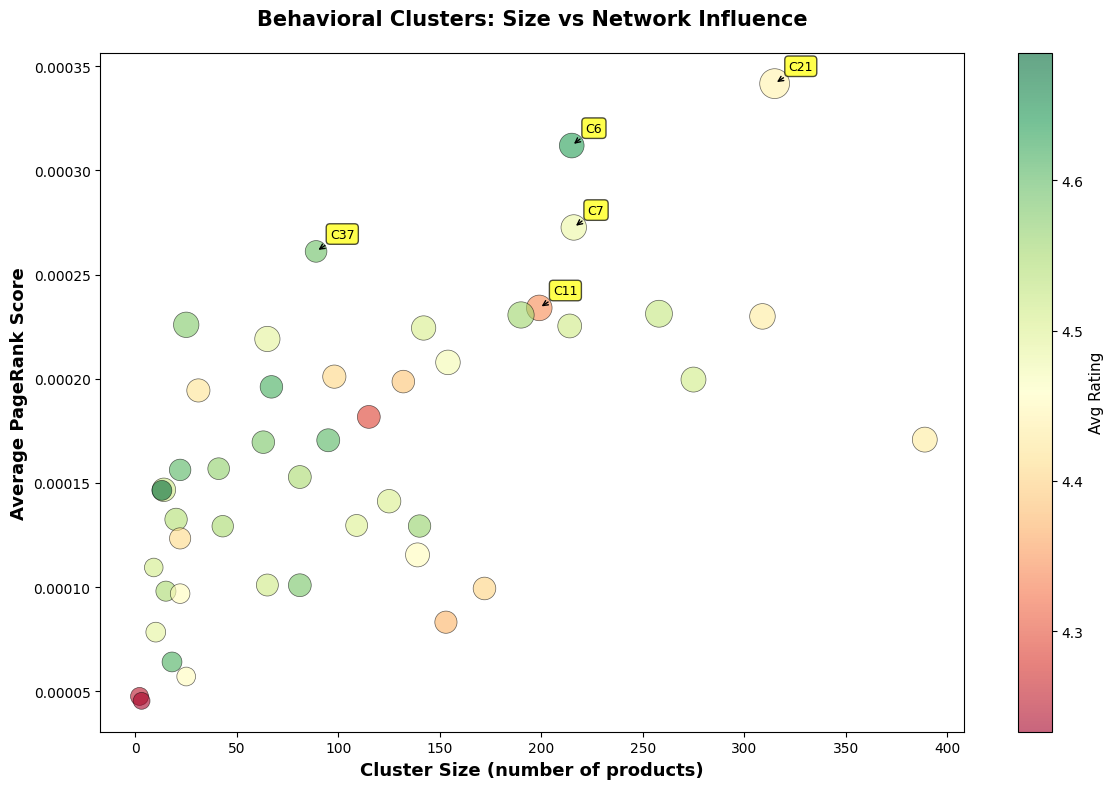

In [ ]:
#----------CLUSTER SIZE vs AVERAGE PAGERANK----------
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    cluster_stats_pd['products'],
    cluster_stats_pd['avg_pagerank'],
    s=cluster_stats_pd['avg_review_count'] / 10,  #Size by popularity
    c=cluster_stats_pd['avg_rating'],
    cmap = 'RdYlGn',
    alpha = 0.6,
    edgecolors = 'black',
    linewidth = 0.5
)

ax.set_xlabel('Cluster Size (number of products)', fontsize = 13, fontweight = 'bold')
ax.set_ylabel('Average PageRank Score', fontsize = 13, fontweight = 'bold')
ax.set_title('Behavioral Clusters: Size vs Network Influence', fontsize = 15, fontweight = 'bold', pad = 20)

#Colorbar for ratings
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Avg Rating', fontsize=11)

#Annotate top 5 clusters
top_5 = cluster_stats_pd.nlargest(5, 'avg_pagerank')
for idx, row in top_5.iterrows():
    ax.annotate(
        f"C{int(row['prediction'])}",
        xy = (row['products'], row['avg_pagerank']),
        xytext = (10, 10),
        textcoords = 'offset points',
        fontsize = 9,
        bbox=dict(boxstyle = 'round,pad=0.3', facecolor = 'yellow', alpha = 0.7),
        arrowprops=dict(arrowstyle = '->', connectionstyle = 'arc3,rad=0', lw = 1)
    )

plt.tight_layout()
plt.show()

####**Visualization 2: PageRank Distribution Across Clusters**

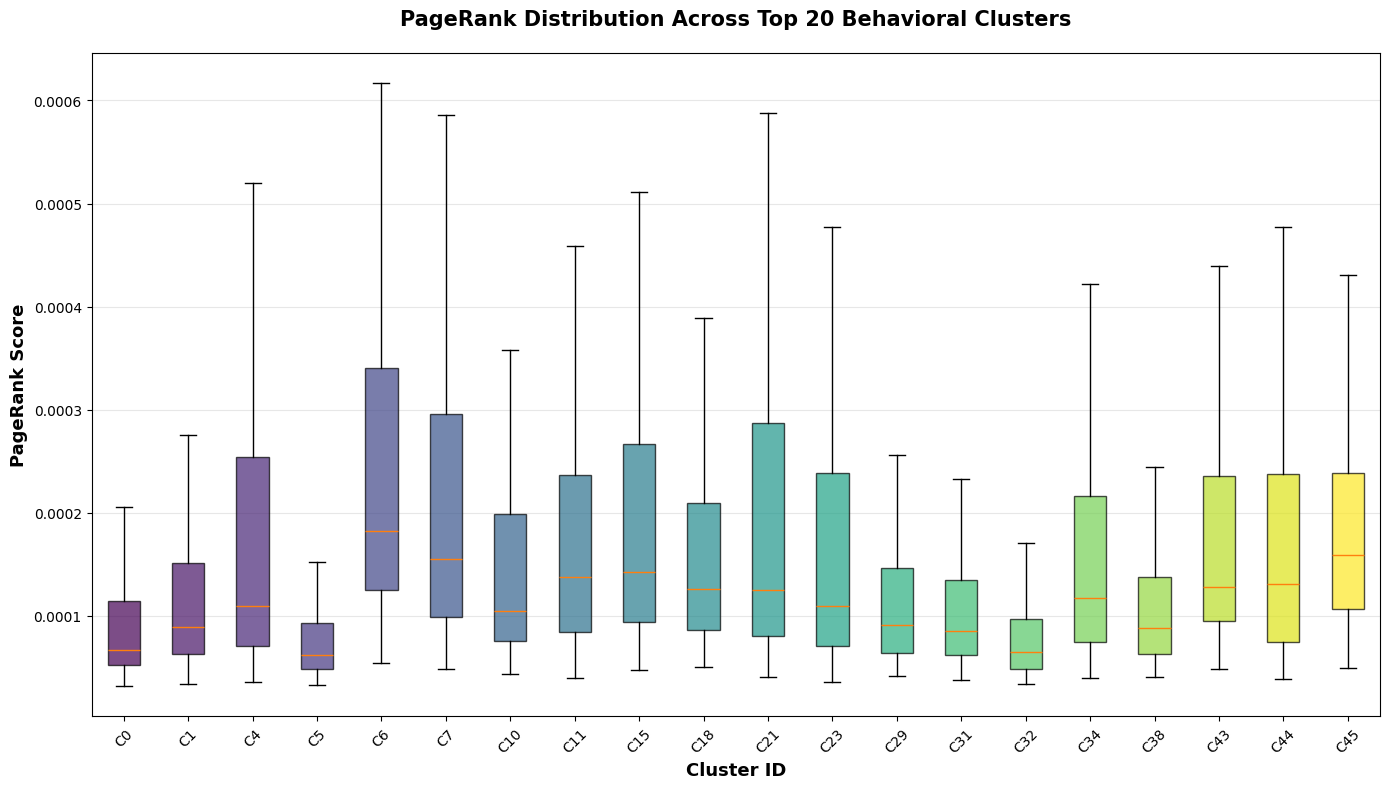

In [ ]:
#----------BOX PLOT----------

#Top 20 clusters by size
top_clusters = cluster_stats_pd.nlargest(20, 'products')['prediction'].values
final_top = final_pd[final_pd['prediction'].isin(top_clusters)]

fig, ax = plt.subplots(figsize=(14, 8))

#Create Box plot
box_parts = ax.boxplot(
    [final_top[final_top['prediction'] == c]['pagerank'].values for c in sorted(top_clusters)],
    positions = range(len(top_clusters)),
    patch_artist = True,
    showfliers = False
)

#Color boxes by median PageRank
medians = [np.median(final_top[final_top['prediction'] == c]['pagerank']) for c in sorted(top_clusters)]
colors = plt.cm.viridis(np.linspace(0, 1, len(medians)))
for patch, color in zip(box_parts['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xlabel('Cluster ID', fontsize = 13, fontweight = 'bold')
ax.set_ylabel('PageRank Score', fontsize = 13, fontweight = 'bold')
ax.set_title('PageRank Distribution Across Top 20 Behavioral Clusters', fontsize = 15, fontweight = 'bold', pad = 20)
ax.set_xticklabels([f"C{int(c)}" for c in sorted(top_clusters)], rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

####**Visualization 3: Influence Concentration Heatmap**

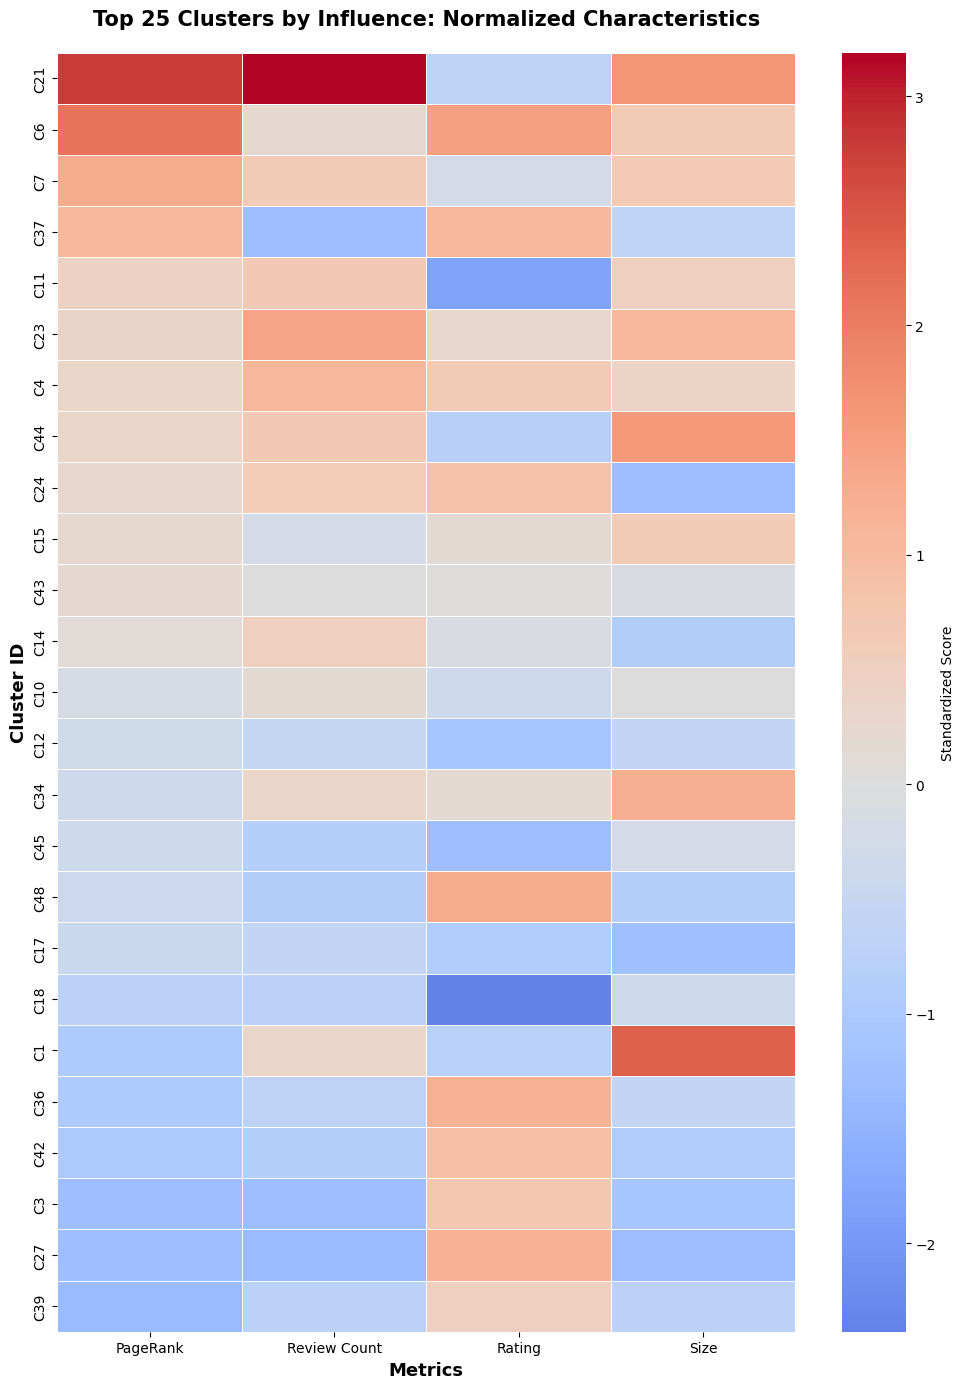

In [ ]:
#----------CLUSTER CHARACTERISTICS----------

#Top 25 clusters by influence
top_25_influence = cluster_stats_pd.nlargest(25, 'avg_pagerank').copy()

#Normalize
scaler = StandardScaler()

heatmap_data = top_25_influence[['avg_pagerank', 'avg_review_count', 'avg_rating', 'products']].copy()
heatmap_data_scaled = pd.DataFrame(
    scaler.fit_transform(heatmap_data),
    columns=['PageRank', 'Review Count', 'Rating', 'Size'],
    index=[f"C{int(x)}" for x in top_25_influence['prediction']]
)

fig, ax = plt.subplots(figsize=(10, 14))

sns.heatmap(
    heatmap_data_scaled,
    annot=False,
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Standardized Score'},
    ax=ax
)

ax.set_title('Top 25 Clusters by Influence: Normalized Characteristics',
             fontsize = 15, fontweight = 'bold', pad = 20)
ax.set_xlabel('Metrics', fontsize = 13, fontweight = 'bold')
ax.set_ylabel('Cluster ID', fontsize = 13, fontweight = 'bold')

plt.tight_layout()
plt.show()

####**Visualization 4: PageRank vs Popularity**

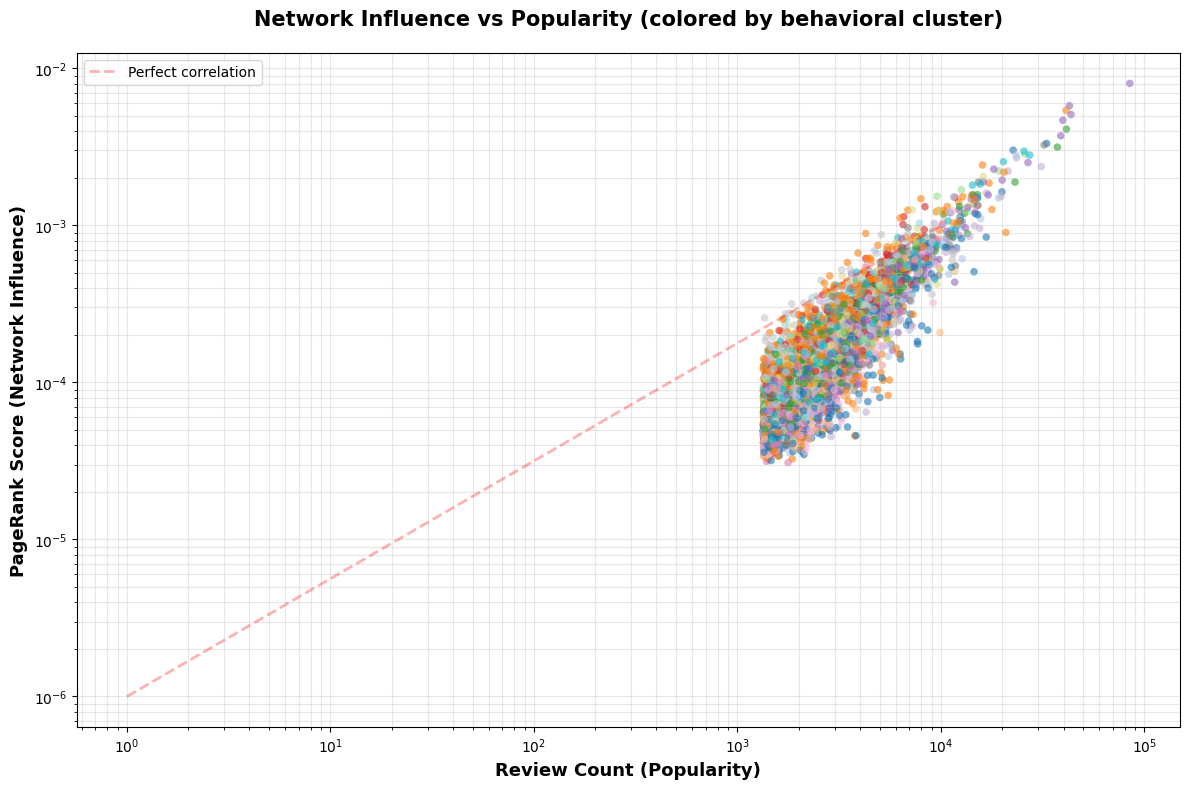

In [ ]:
#----------PAGERANK VS REVIEW COUNT----------

#Sample
sample_size = min(5000, len(final_pd))
final_sample = final_pd.sample(n = sample_size, random_state=42)

fig, ax = plt.subplots(figsize=(12, 8))

#Scatter plot with cluster colors
scatter = ax.scatter(
    final_sample['review_count'],
    final_sample['pagerank'],
    c=final_sample['prediction'],
    cmap = 'tab20',
    alpha = 0.6,
    s = 30,
    edgecolors = 'none'
)

ax.set_xlabel('Review Count (Popularity)', fontsize = 13, fontweight = 'bold')
ax.set_ylabel('PageRank Score (Network Influence)', fontsize = 13, fontweight = 'bold')
ax.set_title('Network Influence vs Popularity (colored by behavioral cluster)',
             fontsize=15, fontweight = 'bold', pad = 20)
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, alpha = 0.3, which = 'both')

#Reference line
ax.plot([1, 10000], [1e-6, 1e-3], 'r--', alpha = 0.3, linewidth = 2, label = 'Perfect correlation')
ax.legend()

plt.tight_layout()
plt.show()

####**Visualization 5: Influence Concentration by Cluster**

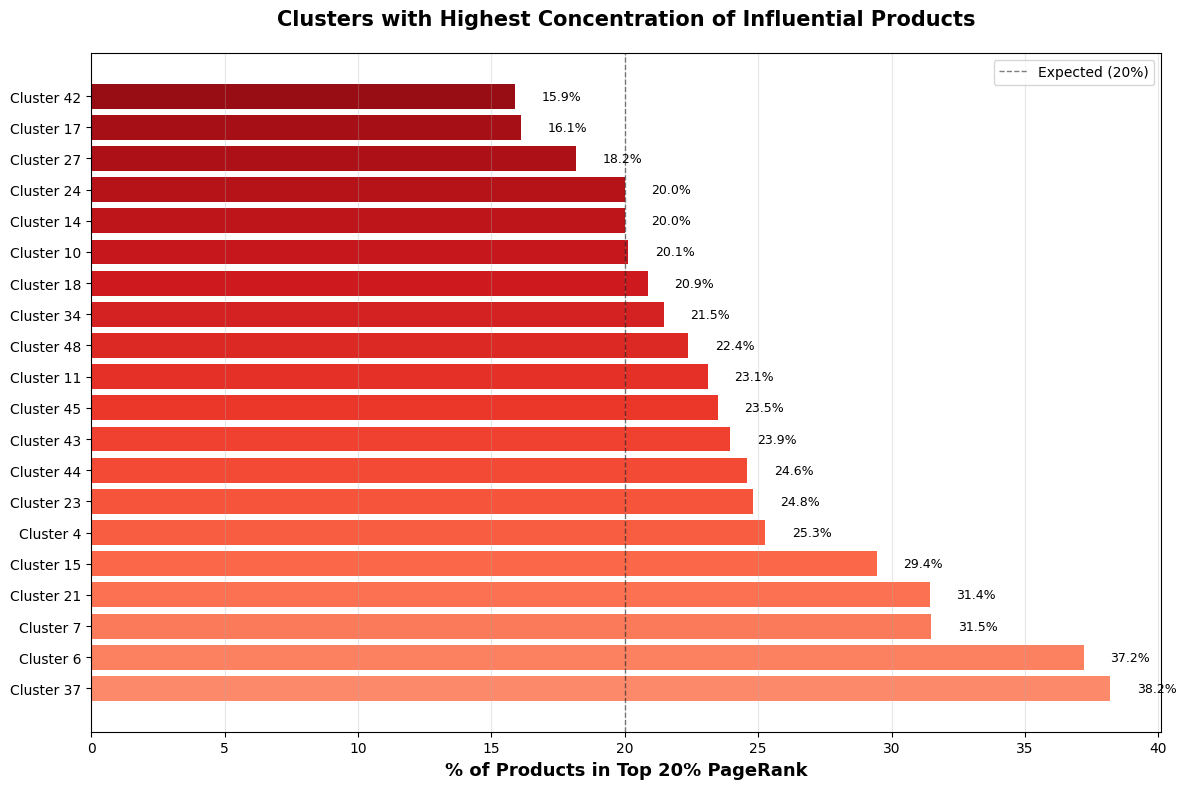

In [ ]:
#----------HIGH-INFLUENCE PRODUCT CONCENTRATION----------

#Calculate percentile for "influential"
percentile_80 = final_pd['pagerank'].quantile(0.8)
final_pd['is_influential'] = (final_pd['pagerank'] >= percentile_80).astype(int)

#Aggregate by cluster
influence_by_cluster = (final_pd
    .groupby('prediction')
    .agg({
        'parent_asin': 'count',
        'is_influential': 'sum'
    })
    .rename(columns={'parent_asin': 'total', 'is_influential': 'influential'})
)
influence_by_cluster['pct_influential'] = (
    influence_by_cluster['influential'] / influence_by_cluster['total'] * 100
)

#Top 20 clusters by concentration
top_20_conc = influence_by_cluster.nlargest(20, 'pct_influential')

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    range(len(top_20_conc)),
    top_20_conc['pct_influential'],
    color=plt.cm.Reds(np.linspace(0.4, 0.9, len(top_20_conc)))
)

ax.set_yticks(range(len(top_20_conc)))
ax.set_yticklabels([f"Cluster {int(x)}" for x in top_20_conc.index])
ax.set_xlabel('% of Products in Top 20% PageRank', fontsize = 13, fontweight = 'bold')
ax.set_title('Clusters with Highest Concentration of Influential Products',
             fontsize=15, fontweight = 'bold', pad = 20)
ax.axvline(20, color='black', linestyle='--', linewidth = 1, alpha = 0.5, label = 'Expected (20%)')
ax.legend()
ax.grid(axis = 'x', alpha = 0.3)

#Bar annotation
for i, (idx, row) in enumerate(top_20_conc.iterrows()):
    ax.text(row['pct_influential'] + 1, i, f"{row['pct_influential']:.1f}%",
            va='center', fontsize=9)

plt.tight_layout()
plt.show()

####**Visualization 6: Correlation Matrix**

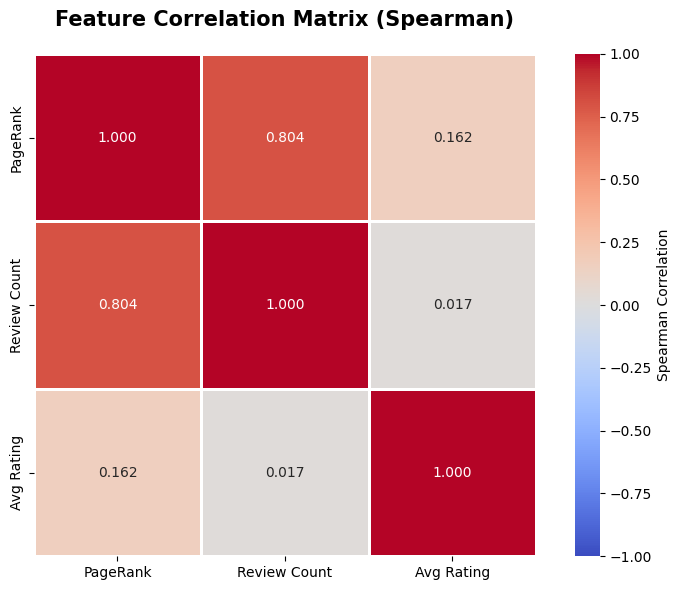

In [ ]:
#----------FEATURE CORRELATIONS----------

corr_data = final_pd[['pagerank', 'review_count', 'average_rating']].copy()
corr_data.columns = ['PageRank', 'Review Count', 'Avg Rating']

#Compute correlations
corr_matrix = corr_data.corr(method = 'spearman')

fig, ax = plt.subplots(figsize = (8, 6))

sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = '.3f',
    cmap = 'coolwarm',
    center = 0,
    square = True,
    linewidths = 2,
    cbar_kws = {'label': 'Spearman Correlation'},
    vmin = -1,
    vmax = 1,
    ax = ax
)

ax.set_title('Feature Correlation Matrix (Spearman)',
             fontsize = 15, fontweight = 'bold', pad = 20)

plt.tight_layout()
plt.show()

####**Visualization 7: Top Products per High-Influence Cluster**

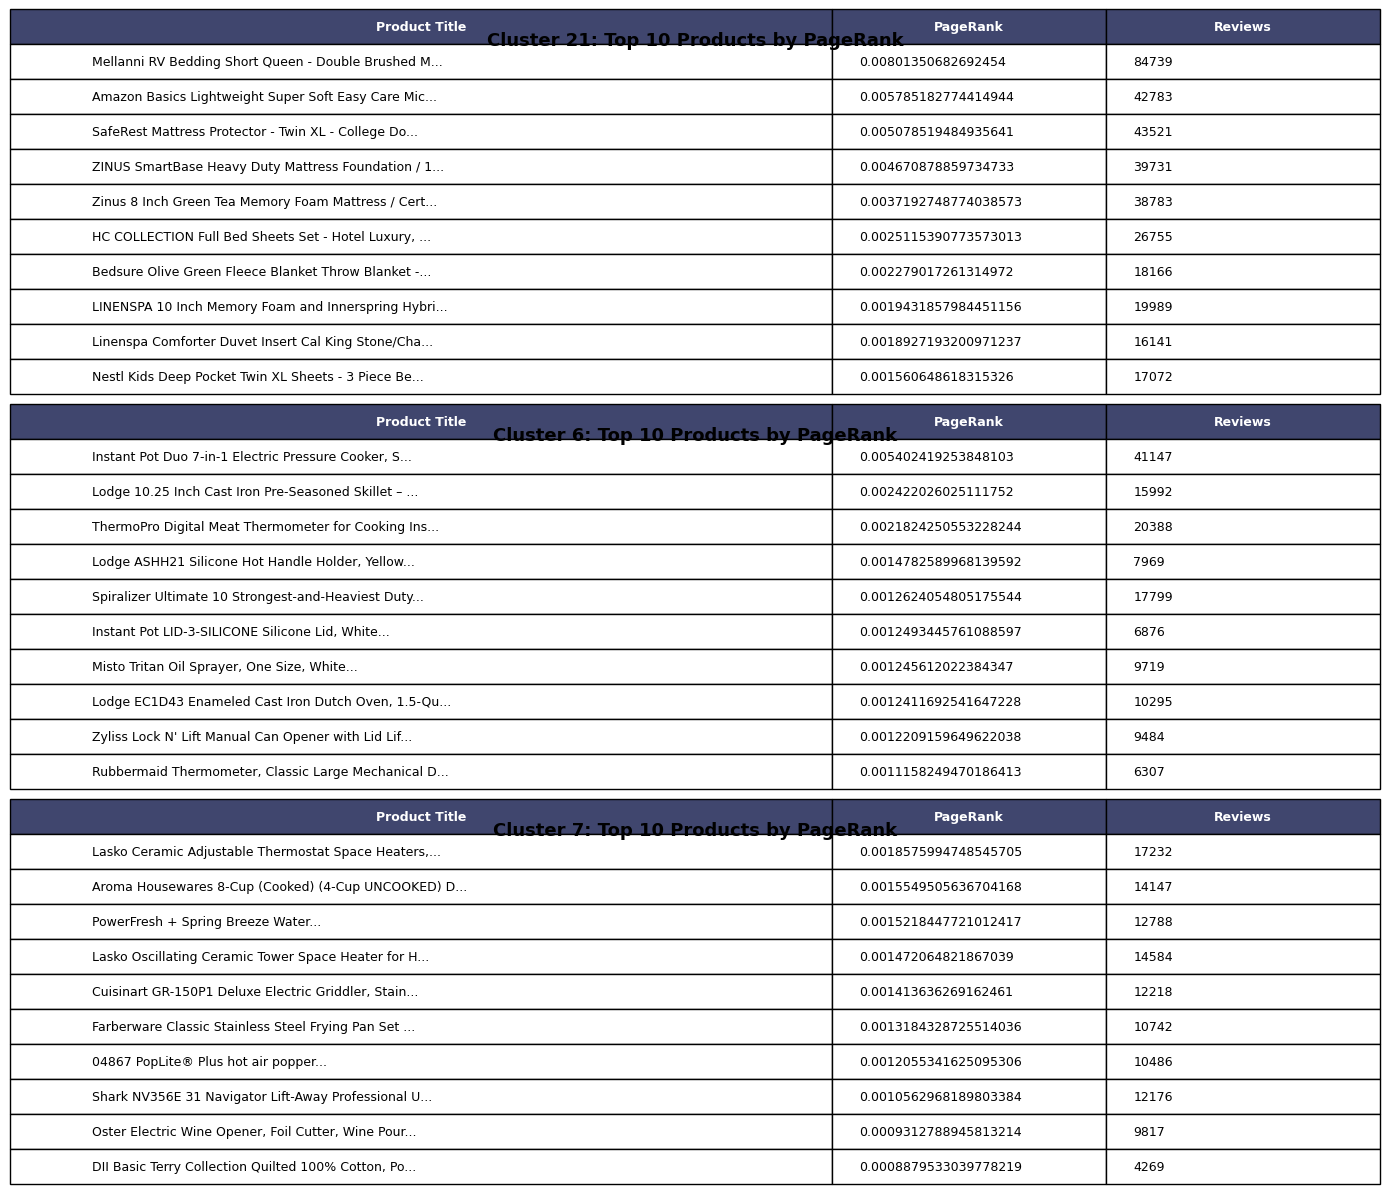

In [ ]:
#----------TOP PRODUCTS IN INFLUENTIAL CLUSTERS----------

#Top 3 clusters by Average PageRank
top_3_clusters = cluster_stats_pd.nlargest(3, 'avg_pagerank')['prediction'].values

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for idx, cluster_id in enumerate(top_3_clusters):
    cluster_products = (final_pd[final_pd['prediction'] == cluster_id]
        .nlargest(10, 'pagerank')[['title', 'pagerank', 'review_count']])

    cluster_products['title'] = cluster_products['title'].str[:50] + '...'

    ax = axes[idx]

    table_data = cluster_products.values
    table = ax.table(
        cellText=table_data,
        colLabels=['Product Title', 'PageRank', 'Reviews'],
        cellLoc='left',
        loc='center',
        colWidths=[0.6, 0.2, 0.2]
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)

    for i in range(3):
        table[(0, i)].set_facecolor('#40466e')
        table[(0, i)].set_text_props(weight = 'bold', color = 'white')

    ax.set_title(f"Cluster {int(cluster_id)}: Top 10 Products by PageRank",
                 fontsize = 13, fontweight = 'bold', pad = 10)
    ax.axis('off')

plt.tight_layout()
plt.show()

####**Summary Statistics**

In [ ]:
#----------SUMMARY REPORT----------

summary = f"""
Dataset Overview:
- Total products analyzed: {len(final_pd):,}
- Number of clusters: {final_pd['prediction'].nunique()}
- Products with PageRank data: {len(final_pd):,}

PageRank Statistics:
- Mean: {final_pd['pagerank'].mean():.6f}
- Median: {final_pd['pagerank'].median():.6f}
- 80th percentile: {final_pd['pagerank'].quantile(0.8):.6f}

Cluster Statistics:
- Avg cluster size: {cluster_stats_pd['products'].mean():.0f} products
- Largest cluster: {cluster_stats_pd['products'].max()} products
- Smallest cluster: {cluster_stats_pd['products'].min()} products

Influence Concentration:
- Clusters with >30% influential products: {len(influence_by_cluster[influence_by_cluster['pct_influential'] > 30])}
- Top cluster influence rate: {influence_by_cluster['pct_influential'].max():.1f}%

Correlations (Spearman):
- PageRank vs Review Count: {corr_data.corr(method='spearman').loc['PageRank', 'Review Count']:.3f}
- PageRank vs Rating: {corr_data.corr(method='spearman').loc['PageRank', 'Avg Rating']:.3f}
"""

print(summary)

#Save summary
with open(f"{OUTPUT_DIR}/summary_statistics.txt", 'w') as f:
    f.write(summary)


Dataset Overview:
- Total products analyzed: 5,000
- Number of clusters: 46
- Products with PageRank data: 5,000

PageRank Statistics:
- Mean: 0.000200
- Median: 0.000109
- 80th percentile: 0.000244

Cluster Statistics:
- Avg cluster size: 109 products
- Largest cluster: 389 products
- Smallest cluster: 2 products

Influence Concentration:
- Clusters with >30% influential products: 4
- Top cluster influence rate: 38.2%

Correlations (Spearman):
- PageRank vs Review Count: 0.804
- PageRank vs Rating: 0.162

